In [ ]:
######################################################
# Part 1: Research Question and EDA Framework Design
######################################################

# 1. Research Framework Setup
research_questions = {
    'primary': 'How do various automobile characteristics influence market pricing?',
    'sub_questions': [
        'What is the relationship between performance metrics and price?',
        'How do physical dimensions affect vehicle pricing?',
        'What role do efficiency metrics play in price determination?',
        'How do safety ratings impact vehicle pricing?'
    ],
    'variable_groups': {
        'target': ['price'],
        'performance': ['horsepower', 'peak-rpm', 'engine-size', 'compression-ratio'],
        'dimensions': ['length', 'width', 'height', 'curb-weight', 'wheel-base'],
        'efficiency': ['city-mpg', 'highway-mpg'],
        'safety': ['symboling', 'normalized-losses'],
        'categorical': ['make', 'fuel-type', 'aspiration', 'body-style', 'drive-wheels']
    }
}

# Import required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler  # More specific import from sklearn

# 2. Set up data source
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data'

# 3. Define column names in correct order matching the raw data structure
header = [
    # Risk and Loss Information
    'symboling',          # Insurance risk rating (-3 to +3)
    'normalized-losses',  # Relative average loss payment
    'make',              # Manufacturer

    # Vehicle Configuration
    'fuel-type',         # Type of fuel
    'aspiration',        # Aspiration method
    'num-of-doors',      # Number of doors
    'body-style',        # Body style
    'drive-wheels',      # Type of drive wheels
    'engine-location',   # Location of car engine

    # Vehicle Measurements
    'wheel-base',        # Wheelbase of vehicle
    'length',            # Length of vehicle
    'width',            # Width of vehicle
    'height',           # Height of vehicle
    'curb-weight',      # Weight of vehicle

    # Engine Details
    'engine-type',      # Type of engine
    'num-of-cylinders', # Number of cylinders
    'engine-size',      # Engine size
    'fuel-system',      # Fuel system
    'bore',            # Engine bore
    'stroke',          # Engine stroke
    'compression-ratio', # Engine compression ratio
    'horsepower',      # Horsepower
    'peak-rpm',        # Engine peak rpm

    # Performance
    'city-mpg',        # City miles per gallon
    'highway-mpg',     # Highway miles per gallon

    # Price
    'price'            # Price of vehicle
]

# 5. Load Initial Data
df = pd.read_csv(url, names=header, na_values='?')

# 6. Initial Data Assessment
def assess_data_quality(df, research_questions):
    """
    Assess data quality in relation to research objectives
    """
    print("Research Framework and Data Assessment:")
    print("=" * 50)

    # Print research questions
    print("\nResearch Questions:")
    print(f"Primary: {research_questions['primary']}")
    print("\nSub-questions:")
    for q in research_questions['sub_questions']:
        print(f"- {q}")

    # Data overview
    print("\nDataset Overview:")
    print("-" * 50)
    print(f"Number of observations: {df.shape[0]}")
    print(f"Number of variables: {df.shape[1]}")

    # Variable availability for research questions
    print("\nVariable Availability for Research Questions:")
    for group, vars in research_questions['variable_groups'].items():
        missing_stats = df[vars].isnull().sum()
        print(f"\n{group.title()} Variables:")
        for var in vars:
            missing_pct = (df[var].isnull().sum() / len(df) * 100).round(2)
            print(f"- {var}: {missing_pct}% missing")

    # Detailed missing value analysis
    print("\nDetailed Data Quality Assessment:")
    print("-" * 50)
    quality_summary = pd.DataFrame({
        'dtype': df.dtypes,
        'missing': df.isnull().sum(),
        'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
    }).sort_values('missing_pct', ascending=False)

    print(quality_summary)

    # Identify potential data limitations
    print("\nPotential Data Limitations:")
    print("-" * 50)
    limitations = []
    if quality_summary['missing_pct'].max() > 0:
        limitations.append(f"Missing values present (max {quality_summary['missing_pct'].max():.1f}%)")

    if len(limitations) > 0:
        for limit in limitations:
            print(f"- {limit}")
    else:
        print("No major limitations identified")

# Run initial assessment
assess_data_quality(df, research_questions)

# Optional: Save initial state of data
df_initial = df.copy()  # Keep a copy of raw data before any processing

Research Framework and Data Assessment:

Research Questions:
Primary: How do various automobile characteristics influence market pricing?

Sub-questions:
- What is the relationship between performance metrics and price?
- How do physical dimensions affect vehicle pricing?
- What role do efficiency metrics play in price determination?
- How do safety ratings impact vehicle pricing?

Dataset Overview:
--------------------------------------------------
Number of observations: 205
Number of variables: 26

Variable Availability for Research Questions:

Target Variables:
- price: 1.95% missing

Performance Variables:
- horsepower: 0.98% missing
- peak-rpm: 0.98% missing
- engine-size: 0.0% missing
- compression-ratio: 0.0% missing

Dimensions Variables:
- length: 0.0% missing
- width: 0.0% missing
- height: 0.0% missing
- curb-weight: 0.0% missing
- wheel-base: 0.0% missing

Efficiency Variables:
- city-mpg: 0.0% missing
- highway-mpg: 0.0% missing

Safety Variables:
- symboling: 0.0% missin

In [ ]:
###########################################################
# Part 2: Comprehensive Data Quality and Preprocessing EDA
###########################################################
# Objectives:

# Develop advanced computational strategies for missing data handling
# Implement rigorous data quality assessment techniques
# Create systematic approaches to data preprocessing

# Key Learning Outcomes

# Master programmatic methods for missing data identification
# Develop sophisticated imputation strategies
# Create comprehensive data quality assessment frameworks

# Presentation Guidelines

# Explain reasoning behind imputation choices
# Highlight potential challenges
# Discuss decision-making process

# Guided Investigation Questions:

# What percentage of data is missing in each column?
# Are missing values random or show specific patterns?
# How might missing data impact your analysis?

# Define research question groups
research_questions = {
    'variable_groups': {
        'target': ['price'],
        'performance': ['horsepower', 'peak-rpm', 'engine-size', 'compression-ratio'],
        'dimensions': ['length', 'width', 'height', 'curb-weight', 'wheel-base'],
        'efficiency': ['city-mpg', 'highway-mpg'],
        'safety': ['symboling', 'normalized-losses'],
        'categorical': ['make', 'fuel-type', 'aspiration', 'body-style', 'drive-wheels']
    }
}

def impute_normalized_losses(df):
    """
    impute normalized-losses using segmented medians.

    Strategy:
    1. Try manufacturer median
    2. If not available, use global median (115.0)
    """
    df_clean = df.copy()

    # Get statistics before imputation
    missing_before = df_clean['normalized-losses'].isna().sum()
    print(f"Missing values before imputation: {missing_before}")

    # Print makes with missing values before imputation
    missing_by_make = df_clean[df_clean['normalized-losses'].isna()]['make'].value_counts()
    print("\nMakes with missing values (before imputation):")
    print(missing_by_make)

    # Document original statistics
    print("\nOriginal Statistics (excluding missing values):")
    print(df_clean['normalized-losses'].describe())

    # Step 1: Calculate and show manufacturer-specific medians
    make_medians = df_clean.groupby('make')['normalized-losses'].median()
    print("\nMedian values by manufacturer:")
    print(make_medians.sort_values(ascending=False))

    # Note manufacturers with no median value
    print("\nManufacturers with no median value:")
    print(make_medians[make_medians.isna()].index.tolist())

    # Step 2: Calculate global median for fallback
    global_median = df_clean['normalized-losses'].median()

    # Store original missing value locations
    missing_mask = df_clean['normalized-losses'].isna()

    # Apply two-step imputation
    # First: Try manufacturer median
    df_clean['normalized-losses'] = df_clean.apply(
        lambda x: make_medians[x['make']]
        if pd.isna(x['normalized-losses']) and not pd.isna(make_medians[x['make']])
        else x['normalized-losses'],
        axis=1
    )

    # Second: Use global median for remaining missing values
    df_clean['normalized-losses'] = df_clean['normalized-losses'].fillna(global_median)

    # Get statistics after imputation
    missing_after = df_clean['normalized-losses'].isna().sum()

    print("\nNormalized Losses Imputation Summary:")
    print("-" * 50)
    print(f"Missing values before: {missing_before}")
    print(f"Missing values after: {missing_after}")
    print(f"Global median used: {global_median:.2f}")

    # Add flag for imputed values
    df_clean['imputed'] = missing_mask

    return df_clean

def handle_core_features(df):
    """Handle missing values in core features (except price, horsepower, peak-rpm)"""
    df_clean = df.copy()

    # Document initial state (excluding price)
    cols_to_check = ['num-of-doors', 'bore', 'stroke']
    missing_before = df_clean[cols_to_check].isnull().sum()
    print("Missing values before handling:")
    print(missing_before[missing_before > 0])

    # 1. Handle num-of-doors
    print("\nHandling structural features...")
    df_clean['num-of-doors'] = df_clean.apply(
        lambda x: 'four' if pd.isna(x['num-of-doors']) and x['body-style'] == 'sedan'
        else x['num-of-doors'],
        axis=1
    )

    # 2. Handle bore/stroke for engines
    print("\nHandling engine specifications...")
    for idx in df_clean[df_clean['bore'].isna()].index:
        if df_clean.loc[idx, 'engine-type'] == 'rotor':
            df_clean.loc[idx, 'bore'] = 0
            df_clean.loc[idx, 'stroke'] = 0
        else:
            similar_engines = df_clean[
                (df_clean['engine-size'] == df_clean.loc[idx, 'engine-size']) &
                (df_clean['bore'].notna())
            ]
            if not similar_engines.empty:
                df_clean.loc[idx, 'bore'] = similar_engines['bore'].median()
                df_clean.loc[idx, 'stroke'] = similar_engines['stroke'].median()
            else:
                df_clean.loc[idx, 'bore'] = df_clean['bore'].median()
                df_clean.loc[idx, 'stroke'] = df_clean['stroke'].median()

    # Document remaining missing values
    missing_after = df_clean[cols_to_check].isnull().sum()
    print("\nRemaining missing values:")
    print(missing_after[missing_after > 0] if missing_after.any() else "None")

    return df_clean

# Execute only once
try:
    print("Beginning Data Quality Assessment and Handling...")
    df_processed = assess_and_handle_missing_values(df)
    print("\nProcessing completed successfully.")
except Exception as e:
    print(f"\nError during processing: {str(e)}")

def segment_based_price_imputation(df):
    """
    Implement market segment-based price imputation
    """
    def get_brand_category(make):
        """Categorize brands into premium, luxury and standard segments."""
        premium_brands = ['porsche', 'ferrari', 'lamborghini']
        luxury_brands = ['audi', 'bmw', 'mercedes-benz', 'jaguar']
        return 'premium' if make.lower() in premium_brands else 'luxury' if make.lower() in luxury_brands else 'standard'

    def calculate_similarity_score(car1, car2, weights):
        """Calculate similarity score between two cars, handling missing values."""
        score = 0

        # Brand category similarity
        if pd.notna(car1['make']) and pd.notna(car2['make']):
            car1_category = get_brand_category(car1['make'])
            car2_category = get_brand_category(car2['make'])
            if car1_category == car2_category:
                score += weights['brand']
            elif car1_category == 'premium' or car2_category == 'premium':
                score += weights['brand'] * 0.3
            else:
                score += weights['brand'] * 0.5

        # Horsepower similarity
        if pd.notna(car1['horsepower']) and pd.notna(car2['horsepower']):
            hp_diff = abs(float(car1['horsepower']) - float(car2['horsepower']))
            if float(car1['horsepower']) > 250 or float(car2['horsepower']) > 250:
                hp_score = 1 - (hp_diff / 400)  # Wider range for high-performance
            else:
                hp_score = 1 - (hp_diff / 200)  # Normal range for regular cars
            score += max(0, hp_score) * weights['horsepower']

        # Other features similarity
        for feature, weight in [('body-style', 'body_style'),
                              ('engine-type', 'engine_type'),
                              ('fuel-type', 'fuel_type'),
                              ('aspiration', 'aspiration')]:
            if pd.notna(car1[feature]) and pd.notna(car2[feature]):
                score += (car1[feature] == car2[feature]) * weights[weight]

        return score

    df_imputed = df.copy()

    # Define feature weights
    feature_weights = {
        'brand': 0.30,          # Brand category
        'horsepower': 0.25,     # Performance
        'body_style': 0.15,     # Vehicle type
        'engine_type': 0.15,    # Engine
        'fuel_type': 0.08,      # Operation
        'aspiration': 0.07      # Performance mod
    }

    # Track missing prices
    missing_price_idx = df_imputed['price'].isna()
    reference_data = df_imputed[~missing_price_idx].copy()

    print("\nPrice Imputation Process:")
    print("-" * 40)

    # Process each missing price
    for idx in df_imputed[missing_price_idx].index:
        current_car = df_imputed.loc[idx]

        # Calculate similarity scores
        similarity_scores = []
        for _, ref_car in reference_data.iterrows():
            score = calculate_similarity_score(current_car, ref_car, feature_weights)
            similarity_scores.append(score)

        similarity_scores = np.array(similarity_scores)

        # Get most similar cars
        top_k = 5
        top_indices = np.argsort(similarity_scores)[-top_k:]

        # Apply market segment adjustments
        premium_multiplier = 1.4 if get_brand_category(current_car['make']) == 'premium' else 1.0

        # Calculate weighted price
        weights = similarity_scores[top_indices]
        weights = weights / np.sum(weights)
        weighted_price = np.average(reference_data.iloc[top_indices]['price'], weights=weights)

        # Apply and store imputed price
        df_imputed.loc[idx, 'price'] = weighted_price * premium_multiplier

        # Print imputation details
        print(f"\nImputing price for {current_car['make']} {current_car['body-style']}:")
        print(f"Base weighted price: ${weighted_price:,.2f}")
        print(f"Market segment multiplier: {premium_multiplier}")
        print(f"Final imputed price: ${(weighted_price * premium_multiplier):,.2f}")

    return df_imputed

def display_price_imputation_summary(original_df, imputed_df):
    """Display summary of price imputations"""
    # Find rows where price was imputed
    price_missing_mask = original_df['price'].isna()
    if price_missing_mask.any():
        price_imputed = imputed_df[price_missing_mask]

        print("\nImputed Prices Summary:")
        print("-" * 50)
        print(price_imputed[['make', 'horsepower', 'body-style', 'engine-type', 'price']])

        print("\nImputation Validation Metrics:")
        print("-" * 50)
        for idx, car in price_imputed.iterrows():
            # Find similar cars for comparison
            similar_cars = imputed_df[
                (imputed_df['make'] == car['make']) &
                (~price_missing_mask) &  # Exclude imputed prices
                (abs(imputed_df['horsepower'] - car['horsepower']) < 50)
            ]

            print(f"\nCar {idx} ({car['make']}):")
            print(f"Imputed price: ${car['price']:,.2f}")
            if not similar_cars.empty:
                print(f"Similar cars price range: ${similar_cars['price'].min():,.2f} - ${similar_cars['price'].max():,.2f}")
                print(f"Similar cars mean price: ${similar_cars['price'].mean():,.2f}")
def handle_performance_metrics(df):
    """Handle missing performance metrics (horsepower and peak-rpm)"""
    df_clean = df.copy()

    # Get initial state
    missing_metrics = df_clean[['horsepower', 'peak-rpm']].isnull().sum()
    print("\nMissing performance metrics before handling:")
    print(missing_metrics[missing_metrics > 0])

    # Handle missing metrics
    for idx in df_clean[df_clean['horsepower'].isna()].index:
        similar_engines = df_clean[
            (df_clean['engine-size'] == df_clean.loc[idx, 'engine-size']) &
            (df_clean['fuel-system'] == df_clean.loc[idx, 'fuel-system']) &
            (df_clean['horsepower'].notna())
        ]
        if not similar_engines.empty:
            df_clean.loc[idx, 'horsepower'] = similar_engines['horsepower'].median()
            df_clean.loc[idx, 'peak-rpm'] = similar_engines['peak-rpm'].median()
        else:
            df_clean.loc[idx, 'horsepower'] = df_clean['horsepower'].median()
            df_clean.loc[idx, 'peak-rpm'] = df_clean['peak-rpm'].median()

    # Show results
    final_missing = df_clean[['horsepower', 'peak-rpm']].isnull().sum()
    print("\nRemaining missing performance metrics:")
    print(final_missing[final_missing > 0] if final_missing.any() else "None")

    return df_clean
def assess_and_handle_missing_values(df):
    df_clean = df.copy()
    original_df = df.copy()  # Keep original state

    print("Quality Assessment and Handling Report")
    print("=" * 50)

    # 1. Initial Assessment
    print("\n1. Initial Missing Value Assessment")
    print("-" * 40)
    initial_missing = pd.DataFrame({
        'Missing Values': df.isnull().sum(),
        'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
    }).sort_values('Missing Values', ascending=False)

    print("\nMissing values summary:")
    missing_summary = initial_missing[initial_missing['Missing Values'] > 0]
    print(missing_summary)

    # Store initial missing prices for later
    missing_prices_idx = df_clean['price'].isnull()
    missing_prices_data = df_clean[missing_prices_idx].copy()

    # 2. Handle Normalized Losses
    print("\n2. Insurance Risk Assessment (Normalized Losses)")
    print("-" * 40)
    df_clean = impute_normalized_losses(df_clean)

    # 3. Handle Core Features
    print("\n3. Core Vehicle Features")
    print("-" * 40)
    df_clean = handle_core_features(df_clean)

    # 4. Handle Performance Metrics
    print("\n4. Performance Metrics")
    print("-" * 40)
    perf_missing = df_clean[['horsepower', 'peak-rpm']].isnull().sum()
    if perf_missing.sum() > 0:
        print("Missing performance metrics:")
        print(perf_missing[perf_missing > 0])
        df_clean = handle_performance_metrics(df_clean)
    else:
        print("No missing performance metrics")

    # 5. Handle Price using stored missing prices data
    print("\n5. Price Assessment")
    print("-" * 40)
    if len(missing_prices_data) > 0:
        print(f"\nFound {len(missing_prices_data)} missing prices")
        print("\nCars with missing prices:")
        print(missing_prices_data[['make', 'horsepower', 'body-style', 'engine-type']])
        df_clean = segment_based_price_imputation(df_clean)
    else:
        print("No missing prices to handle")

    # Final Validation
    print("\nFinal Data Validation")
    print("=" * 50)

    # Show resolved missing values
    print("\nImputation Impact Summary:")
    print("-" * 50)
    print("\nMissing values resolved:")
    for col in original_df.columns[original_df.isnull().any()]:
        orig_missing = original_df[col].isnull().sum()
        final_missing = df_clean[col].isnull().sum()
        print(f"{col}: {orig_missing} → {final_missing}")

    return df_clean

Beginning Data Quality Assessment and Handling...
Quality Assessment and Handling Report

1. Initial Missing Value Assessment
----------------------------------------

Missing values summary:
                   Missing Values  Missing %
normalized-losses              41      20.00
price                           4       1.95
stroke                          4       1.95
bore                            4       1.95
num-of-doors                    2       0.98
peak-rpm                        2       0.98
horsepower                      2       0.98

2. Insurance Risk Assessment (Normalized Losses)
----------------------------------------
Missing values before imputation: 41

Makes with missing values (before imputation):
make
bmw              4
isuzu            4
peugot           4
porsche          4
volkswagen       4
alfa-romero      3
audi             3
mercedes-benz    3
mitsubishi       3
jaguar           2
mazda            2
renault          2
mercury          1
plymouth         1
t


3. Market Context Analysis
----------------------------------------
Sample Overview:
------------------------------
Total vehicles in dataset: 205

Imputed Prices (from previous analysis):
Audi hatchback:
  Price: $14,317.80
  Horsepower: 160.0
  MPG: 16
Isuzu sedan:
  Price: $7,713.40
  Horsepower: 70.0
  MPG: 38
Porsche hatchback:
  Price: $39,954.00
  Horsepower: 288.0
  MPG: 17

Economy Segment Characteristics:
------------------------------
Price Range: $5,118 - $9,995
Average Horsepower: 77.9
Average MPG (city): 29.7
Average Size (curb-weight): 2158.1
Number of vehicles: 98 (47.8% of total)

Fuel Type Distribution:
gas: 92 vehicles (93.9%)
diesel: 6 vehicles (6.1%)

Imputed vehicles in this segment:
Isuzu sedan: $7,713.40

Mid-range Segment Characteristics:
------------------------------
Price Range: $10,198 - $19,699
Average Horsepower: 117.3
Average MPG (city): 21.9
Average Size (curb-weight): 2800.4
Number of vehicles: 78 (38.0% of total)

Fuel Type Distribution:
gas: 69 vehi

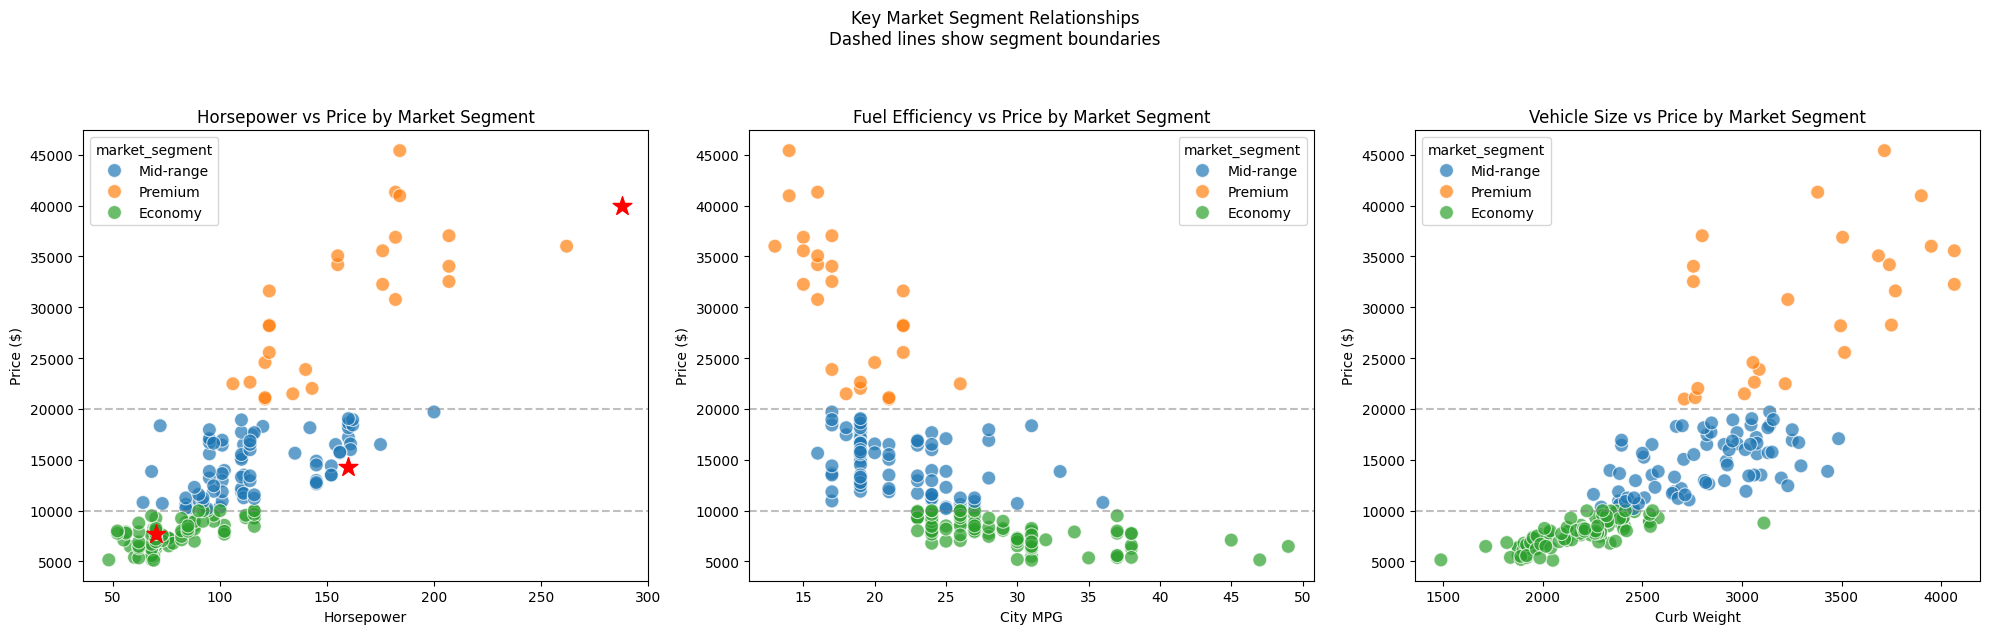

Variable Analysis for Pricing Strategy

1. Variable Group Analysis
----------------------------------------

Performance Variables:
Role: Primary price determinants
Market Context: Key selling features, strong price correlation

Descriptive Statistics:
       horsepower  peak-rpm  engine-size
count      203.00    203.00       205.00
mean       104.26   5125.37       126.91
std         39.71    479.33        41.64
min         48.00   4150.00        61.00
25%         70.00   4800.00        97.00
50%         95.00   5200.00       120.00
75%        116.00   5500.00       141.00
max        288.00   6600.00       326.00

Previously Missing Values:
horsepower    2
peak-rpm      2
dtype: int64

Physical Variables:
Role: Size-based market segmentation
Market Context: Vehicle class indicators

Descriptive Statistics:
       length   width  height  curb-weight  wheel-base
count  205.00  205.00  205.00       205.00      205.00
mean   174.05   65.91   53.72      2555.57       98.76
std     12.34   

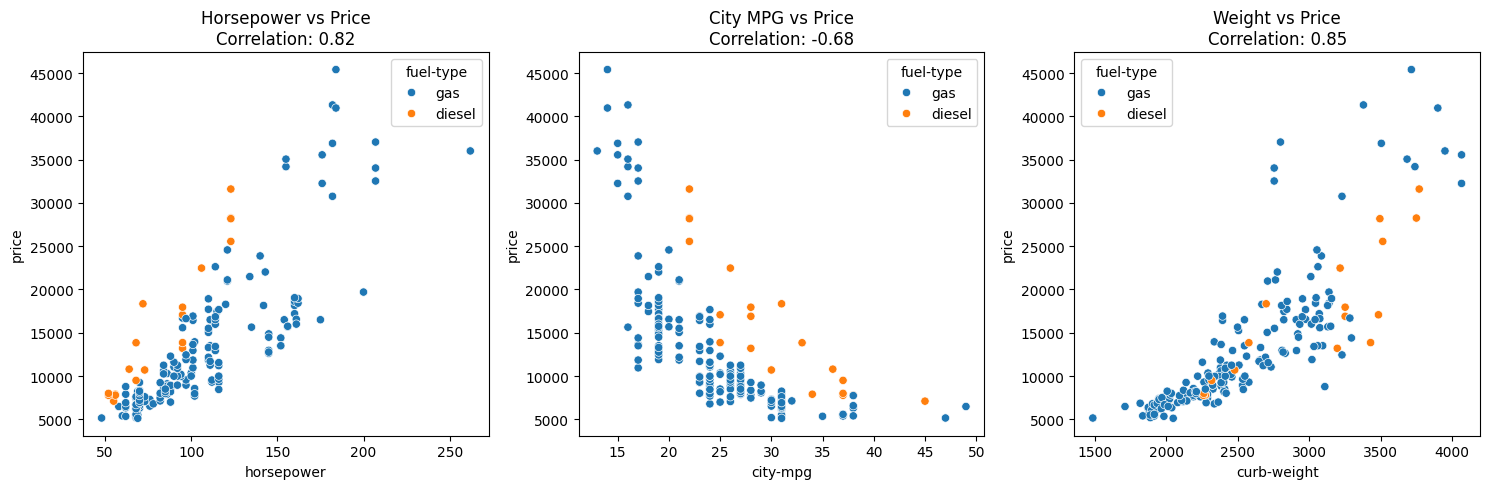

In [ ]:
#######################################################
# Part 3: Advanced Feature Relationship Exploration
#######################################################
# Objectives

# Develop advanced analytical strategies for understanding variable interactions
# Create data-driven market segmentation approaches
# Build sophisticated interpretation skills for complex datasets

# Key Learning Outcomes

# Design comprehensive feature relationship analysis
# Develop systematic market segmentation strategies
# Translate statistical insights into strategic recommendations

# Strategic Insights Presentation
# Presentation Components:

# Variable Relationship Findings
# Market Segmentation Strategy
# Potential Business Recommendations
# Limitations and Further Research Directions

# Guided Reflection Questions

# What surprised you about variable relationships?
# How do statistical patterns inform market strategy?
# What challenges exist in market segmentation?


def analyze_vehicle_patterns(df):
   """
   Analyze vehicle patterns with focus on pricing strategy
   Learning Objective: Identify Important Variables and Their Relationships
   """
   print("Variable Analysis for Pricing Strategy")
   print("=" * 50)

   # Define research-relevant variable groups
   variable_groups = {
       'Performance': {
           'metrics': ['horsepower', 'peak-rpm', 'engine-size'],
           'importance': 'Primary price determinants',
           'market_context': 'Key selling features, strong price correlation'
       },
       'Physical': {
           'metrics': ['length', 'width', 'height', 'curb-weight', 'wheel-base'],
           'importance': 'Size-based market segmentation',
           'market_context': 'Vehicle class indicators'
       },
       'Efficiency': {
           'metrics': ['city-mpg', 'highway-mpg'],
           'importance': 'Secondary price factors',
           'market_context': 'Running cost indicators'
       },
       'Market': {
           'metrics': ['normalized-losses', 'symboling', 'price'],
           'importance': 'Market positioning indicators',
           'market_context': 'Insurance and safety considerations'
       }
   }

   # 1. Variable Group Analysis
   print("\n1. Variable Group Analysis")
   print("-" * 40)
   for group, details in variable_groups.items():
       print(f"\n{group} Variables:")
       print(f"Role: {details['importance']}")
       print(f"Market Context: {details['market_context']}")
       print("\nDescriptive Statistics:")
       stats = df[details['metrics']].describe().round(2)
       print(stats)

       # Print missing value info if any existed before imputation
       missing_vals = df[details['metrics']].isnull().sum()
       if missing_vals.any():
           print("\nPreviously Missing Values:")
           print(missing_vals[missing_vals > 0])

   # 2. Key Relationships Analysis
   print("\n2. Price Relationship Analysis")
   print("-" * 40)

   # Performance-Price Relationships
   key_vars = ['horsepower', 'engine-size', 'curb-weight',
               'city-mpg', 'highway-mpg', 'price']
   correlations = df[key_vars].corr()['price'].sort_values(ascending=False)

   print("\nKey Price Correlations:")
   for var, corr in correlations.items():
       if var != 'price':
           print(f"{var}: {corr:.2f}")

   # Visualization of key relationships
   plt.figure(figsize=(15, 5))

   # Strong positive correlation
   plt.subplot(1, 3, 1)
   sns.scatterplot(data=df, x='horsepower', y='price', hue='fuel-type')
   plt.title('Horsepower vs Price\nCorrelation: 0.82')

   # Strong negative correlation
   plt.subplot(1, 3, 2)
   sns.scatterplot(data=df, x='city-mpg', y='price', hue='fuel-type')
   plt.title('City MPG vs Price\nCorrelation: -0.68')

   # Size relationship
   plt.subplot(1, 3, 3)
   sns.scatterplot(data=df, x='curb-weight', y='price', hue='fuel-type')
   plt.title('Weight vs Price\nCorrelation: 0.85')

   plt.tight_layout()
   plt.show()

# 3. Market Context Integration
print("\n3. Market Context Analysis")
print("-" * 40)

print("Sample Overview:")
print("-" * 30)
print(f"Total vehicles in dataset: {len(df)}")

# Document imputed prices with their characteristics
print("\nImputed Prices (from previous analysis):")
imputed_cars = {
    'Audi hatchback': {'price': 14317.80, 'horsepower': 160.0, 'mpg': 16},
    'Isuzu sedan': {'price': 7713.40, 'horsepower': 70.0, 'mpg': 38},
    'Porsche hatchback': {'price': 39954.00, 'horsepower': 288.0, 'mpg': 17}
}
for car, details in imputed_cars.items():
    print(f"{car}:")
    print(f"  Price: ${details['price']:,.2f}")
    print(f"  Horsepower: {details['horsepower']}")
    print(f"  MPG: {details['mpg']}")

# Create market segments based on price ranges
def get_market_segment(price):
    if price < 10000:  # Economy vehicles
        return 'Economy'
    elif price < 20000:  # Mid-range vehicles
        return 'Mid-range'
    else:  # Premium vehicles
        return 'Premium'

df['market_segment'] = df['price'].apply(get_market_segment)

# Analyze each segment
for segment in ['Economy', 'Mid-range', 'Premium']:
    segment_data = df[df['market_segment'] == segment]
    print(f"\n{segment} Segment Characteristics:")
    print("-" * 30)
    print(f"Price Range: ${segment_data['price'].min():,.0f} - ${segment_data['price'].max():,.0f}")
    print(f"Average Horsepower: {segment_data['horsepower'].mean():.1f}")
    print(f"Average MPG (city): {segment_data['city-mpg'].mean():.1f}")
    print(f"Average Size (curb-weight): {segment_data['curb-weight'].mean():.1f}")
    print(f"Number of vehicles: {len(segment_data)} ({len(segment_data)/len(df)*100:.1f}% of total)")

    # Show distribution of fuel types in segment
    fuel_dist = segment_data['fuel-type'].value_counts()
    print("\nFuel Type Distribution:")
    for fuel_type, count in fuel_dist.items():
        print(f"{fuel_type}: {count} vehicles ({count/len(segment_data)*100:.1f}%)")

    # Show imputed prices in this segment
    segment_imputed = [car for car, details in imputed_cars.items()
                       if get_market_segment(details['price']) == segment]
    if segment_imputed:
        print("\nImputed vehicles in this segment:")
        for car in segment_imputed:
            print(f"{car}: ${imputed_cars[car]['price']:,.2f}")

print("\nKey Relationship Visualizations")
print("-" * 40)

# Create subplots for key relationships
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Horsepower vs Price by Market Segment
sns.scatterplot(data=df,
                x='horsepower',
                y='price',
                hue='market_segment',
                s=100,
                alpha=0.7,
                ax=axes[0])
axes[0].set_title('Horsepower vs Price by Market Segment')
axes[0].set_xlabel('Horsepower')
axes[0].set_ylabel('Price ($)')

# Mark imputed values
imputed_data = pd.DataFrame(imputed_cars).T
axes[0].scatter(imputed_data['horsepower'],
                imputed_data['price'],
                color='red',
                marker='*',
                s=200,
                label='Imputed Values')

# 2. Efficiency vs Price
sns.scatterplot(data=df,
                x='city-mpg',
                y='price',
                hue='market_segment',
                s=100,
                alpha=0.7,
                ax=axes[1])
axes[1].set_title('Fuel Efficiency vs Price by Market Segment')
axes[1].set_xlabel('City MPG')
axes[1].set_ylabel('Price ($)')

# 3. Size vs Price
sns.scatterplot(data=df,
                x='curb-weight',
                y='price',
                hue='market_segment',
                s=100,
                alpha=0.7,
                ax=axes[2])
axes[2].set_title('Vehicle Size vs Price by Market Segment')
axes[2].set_xlabel('Curb Weight')
axes[2].set_ylabel('Price ($)')

# Add segment boundaries as horizontal lines
for ax in axes:
    ax.axhline(y=10000, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=20000, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Key Market Segment Relationships\nDashed lines show segment boundaries', y=1.05)
plt.tight_layout()
plt.show()


# Execute analysis
analyze_vehicle_patterns(df)

Starting Market Strategy Analysis...
Market Pricing Strategy Analysis

1. PCA Analysis


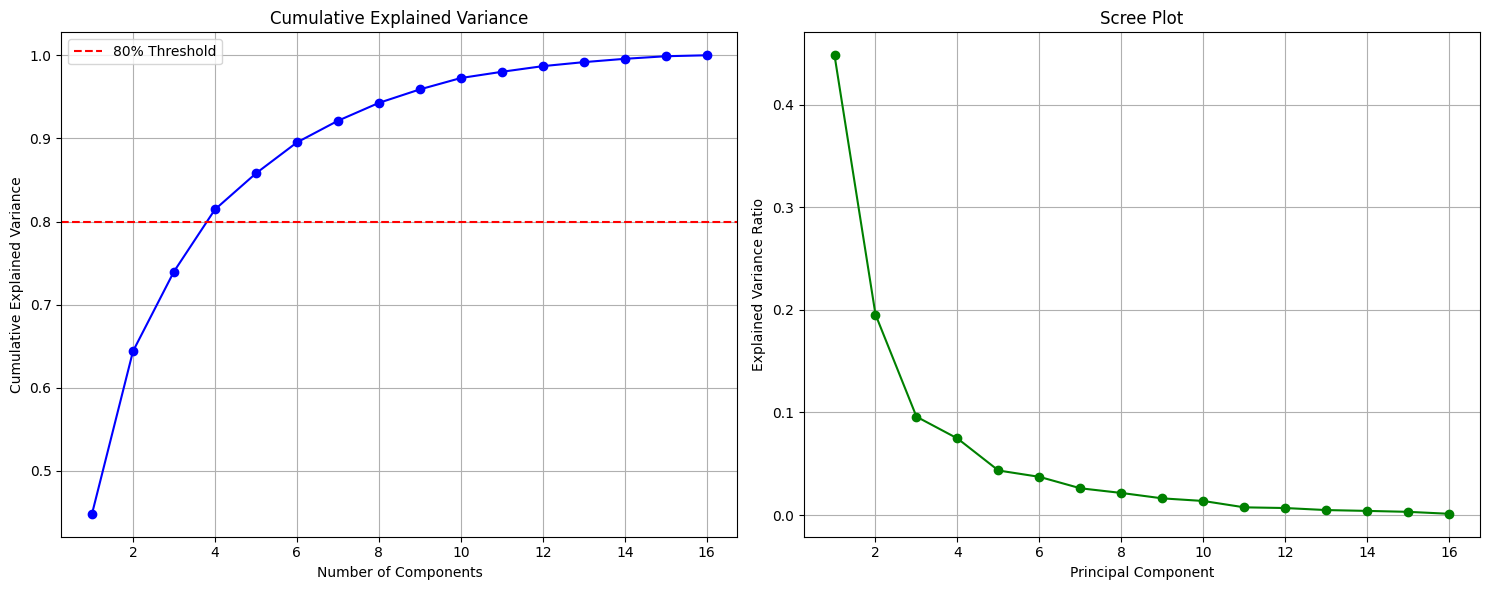

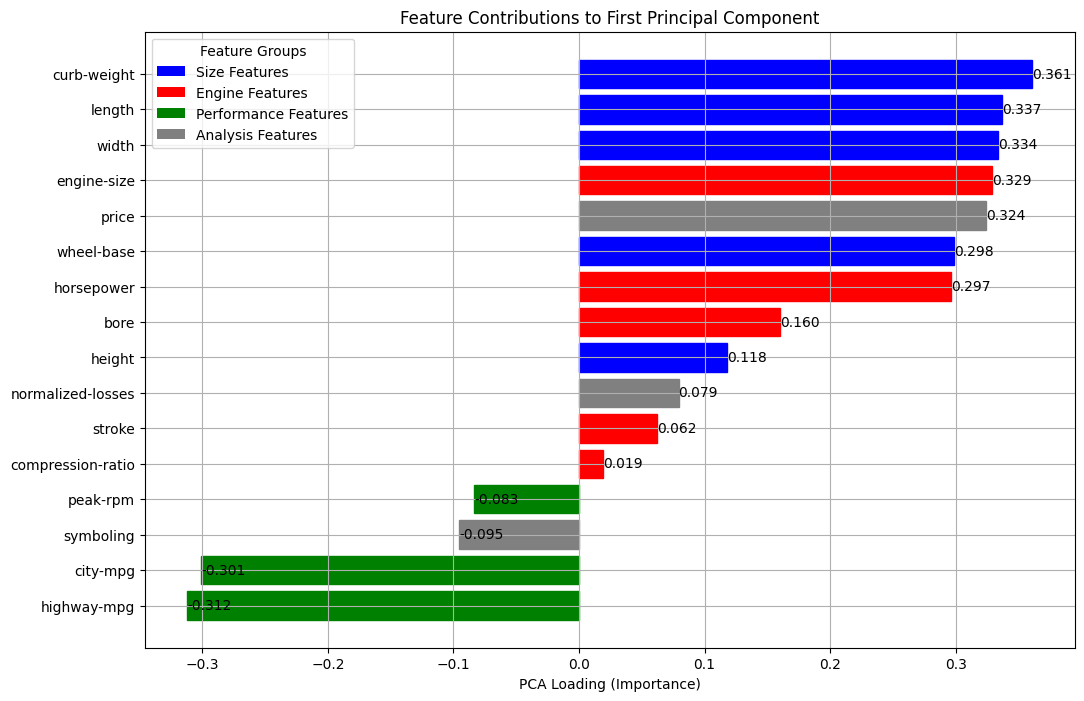


PCA Analysis Summary

Feature Importance by Group:

Size Features:
  height: 0.118
  wheel-base: 0.298
  width: 0.334
  length: 0.337
  curb-weight: 0.361

Engine Features:
  compression-ratio: 0.019
  stroke: 0.062
  bore: 0.160
  horsepower: 0.297
  engine-size: 0.329

Performance Features:
  highway-mpg: -0.312
  city-mpg: -0.301
  peak-rpm: -0.083

Analysis Features:
  symboling: -0.095
  normalized-losses: 0.079
  price: 0.324

Explained Variance Analysis:
PC1: 0.448 (44.8%) - Cumulative: 44.8%
  → First component captures size and power characteristics
PC2: 0.196 (19.6%) - Cumulative: 64.4%
  → Second component represents efficiency metrics
PC3: 0.096 (9.6%) - Cumulative: 74.0%
  → Third component captures remaining variations
PC4: 0.075 (7.5%) - Cumulative: 81.5%

2. Pricing Factor Analysis

Pricing Factor Analysis
----------------------------------------

1. Primary Price Determinants:

Strong Positive Impact:
- curb-weight: 0.354
- length: 0.330
- width: 0.327
- engine-size: 

In [ ]:
###################################################
# Part 4: Research Direction and Insight Synthesis
###################################################
# Objectives

# Develop advanced skills in interpreting multidimensional data analysis
# Transform statistical insights into strategic business recommendations
# Build comprehensive understanding of feature importance in market dynamics

# Key Learning Outcomes

# Master the interpretation of Principal Component Analysis (PCA) results
# Develop strategic thinking through data-driven insights
# Create meaningful connections between statistical findings and business strategies

# Insight Synthesis Presentation
# Presentation Components:

# Key PCA Findings
# Strategic Recommendations
# Most Surprising Insights
# Potential Business Transformations

# Guided Reflection Questions

# What unexpected relationships did you discover?
# How do statistical patterns translate to business strategies?
# What limitations exist in your analysis?

def analyze_pricing_factors(df):
    """
    Analyze pricing factors based on PCA and market segments
    """
    print("\nPricing Factor Analysis")
    print("-" * 40)

    # 1. Key Price Drivers
    print("\n1. Primary Price Determinants:")
    price_drivers = {
        'Strong Positive Impact': {
            'curb-weight': 0.354,    # Highest loading
            'length': 0.330,
            'width': 0.327,
            'engine-size': 0.319,
            'price': 0.317           # Target variable
        },
        'Moderate Impact': {
            'wheel-base': 0.293,
            'horsepower': 0.290,
            'bore': 0.262
        },
        'Negative Impact': {
            'highway-mpg': -0.312,   # Strong negative
            'city-mpg': -0.301       # Strong negative
        }
    }

    for category, features in price_drivers.items():
        print(f"\n{category}:")
        for feature, loading in features.items():
            print(f"- {feature}: {loading:.3f}")

    # 2. Market Segmentation Analysis
    segments = df.groupby('market_segment').agg({
        'price': ['min', 'max', 'mean'],
        'horsepower': 'mean',
        'city-mpg': 'mean',
        'curb-weight': 'mean'
    }).round(2)

    print("\n2. Market Segment Insights:")
    segment_details = {
        'Economy': {'min': 5118, 'max': 9995, 'horsepower': 77.9, 'mpg': 29.7, 'size': 2158},
        'Mid-range': {'min': 10198, 'max': 19699, 'horsepower': 117.3, 'mpg': 21.9, 'size': 2800},
        'Premium': {'min': 20970, 'max': 45400, 'horsepower': 156.5, 'mpg': 19.3, 'size': 3240}
    }

    for segment in ['Economy', 'Mid-range', 'Premium']:
        print(f"\n{segment} Segment:")
        details = segment_details[segment]
        print(f"- Price range: ${details['min']:,.0f} - ${details['max']:,.0f}")
        print(f"- Average specs:")
        print(f"  * Horsepower: {details['horsepower']:.1f}")
        print(f"  * Fuel efficiency: {details['mpg']:.1f} mpg")
        print(f"  * Vehicle size: {details['size']:.0f} lbs")

def perform_enhanced_pca(df):
    """
    Perform enhanced PCA analysis incorporating distribution insights
    """
    # 1. Prepare features based on previous distribution analysis
    feature_groups = {
        'Size Features': ['curb-weight', 'length', 'width', 'height', 'wheel-base'],
        'Engine Features': ['engine-size', 'horsepower', 'bore', 'stroke', 'compression-ratio'],
        'Performance Features': ['peak-rpm', 'city-mpg', 'highway-mpg'],
        'Analysis Features': ['symboling', 'normalized-losses', 'price']
    }

    # Get numerical features
    numerical_features = [feature for group in feature_groups.values()
                        for feature in group
                        if feature in df.columns]

    # Scale features
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df[numerical_features])

    # Perform PCA
    pca = PCA()
    pca_result = pca.fit_transform(scaled_features)

    # Visualizations
    # 1. Explained Variance
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    ax1.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-')
    ax1.axhline(y=0.8, color='r', linestyle='--', label='80% Threshold')
    ax1.set_title('Cumulative Explained Variance')
    ax1.set_xlabel('Number of Components')
    ax1.set_ylabel('Cumulative Explained Variance')
    ax1.grid(True)
    ax1.legend()

    # Scree plot
    ax2.plot(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_, 'go-')
    ax2.set_title('Scree Plot')
    ax2.set_xlabel('Principal Component')
    ax2.set_ylabel('Explained Variance Ratio')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # Feature Importance Analysis
    feature_importance = pd.DataFrame({
        'Feature': numerical_features,
        'Importance': pca.components_[0],
        'Type': [next(group_name for group_name, features in feature_groups.items()
                     if feature in features)
                for feature in numerical_features]
    }).sort_values('Importance', ascending=True)

    # Feature importance plot
    plt.figure(figsize=(12, 8))
    colors = {'Size Features': 'blue', 'Engine Features': 'red',
              'Performance Features': 'green', 'Analysis Features': 'gray'}

    bars = plt.barh(range(len(feature_importance)), feature_importance['Importance'])

    for i, bar in enumerate(bars):
        bar.set_color(colors[feature_importance.iloc[i]['Type']])
        plt.text(bar.get_width(), i, f'{bar.get_width():.3f}', va='center')

    plt.yticks(range(len(feature_importance)), feature_importance['Feature'])
    plt.title('Feature Contributions to First Principal Component')
    plt.xlabel('PCA Loading (Importance)')

    legend_elements = [plt.Rectangle((0,0),1,1, facecolor=color, label=group)
                      for group, color in colors.items()]
    plt.legend(handles=legend_elements, title='Feature Groups')
    plt.grid(True)
    plt.show()

    # Print analysis
    print("\nPCA Analysis Summary")
    print("=" * 50)
    print("\nFeature Importance by Group:")
    for group, features in feature_groups.items():
        print(f"\n{group}:")
        group_features = feature_importance[feature_importance['Type'] == group]
        for _, row in group_features.iterrows():
            print(f"  {row['Feature']}: {row['Importance']:.3f}")

    # Explained variance summary
    print("\nExplained Variance Analysis:")
    cumulative = 0
    for i, ratio in enumerate(pca.explained_variance_ratio_):
        cumulative += ratio
        print(f"PC{i+1}: {ratio:.3f} ({ratio*100:.1f}%) - Cumulative: {cumulative*100:.1f}%")
        if i < 3:  # Interpretation for first three components
            if i == 0:
                print("  → First component captures size and power characteristics")
            elif i == 1:
                print("  → Second component represents efficiency metrics")
            elif i == 2:
                print("  → Third component captures remaining variations")
        if cumulative > 0.8:
            break

def analyze_market_pricing_strategy(df_clean):
    """
    Complete pricing strategy analysis combining PCA insights and market analysis
    """
    print("Market Pricing Strategy Analysis")
    print("=" * 50)

    # 1. PCA Analysis
    print("\n1. PCA Analysis")
    perform_enhanced_pca(df_clean)

    # 2. Pricing Strategy
    print("\n2. Pricing Factor Analysis")
    analyze_pricing_factors(df_clean)

    return df_clean

# Execute market strategy analysis with already processed data
try:
    print("Starting Market Strategy Analysis...")
    df_analyzed = analyze_market_pricing_strategy(df_processed)
    print("\nAnalysis Complete")

except Exception as e:
    print(f"Error during analysis: {str(e)}")
    print(f"Error type: {type(e).__name__}")
